In [133]:
import pandas as pd
import numpy as np

In [134]:
user_chunks = []

for chunk in pd.read_json(
    "../data/raw/yelp_academic_dataset_user.json",
    lines=True,
    chunksize=50000
):
    chunk = chunk[[
        "user_id",
        "review_count",
        "average_stars",
        "yelping_since"
    ]]
    
    user_chunks.append(chunk)

users = pd.concat(user_chunks, ignore_index=True)

users.head()

,user_id,review_count,average_stars,yelping_since
0,qVc8ODYU5SZjKXVBgXdI7w,585,3.91,2007-01-25 16:47:26
1,j14WgRoU_-2ZE1aw1dXrJg,4333,3.74,2009-01-25 04:35:42
2,2WnXYQFK0hXEoTxPtV2zvg,665,3.32,2008-07-25 10:41:00
3,SZDeASXq7o05mMNLshsdIA,224,4.27,2005-11-29 04:38:33
4,hA5lMy-EnncsH4JoR-hFGQ,79,3.54,2007-01-05 19:40:59


In [135]:
users.shape

(1987897, 4)

In [136]:
business = pd.read_json("../data/raw/yelp_academic_dataset_business.json", lines=True)
business.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [137]:
business.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours'],
      dtype='object')

In [138]:
business = business[[
    "business_id",
    "name",
    "stars",
    "review_count",
    "categories"
]]

business.head()

,business_id,name,stars,review_count,categories
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ",5.0,7,"Doctors, Traditional Chinese Medicine, Naturop..."
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,3.0,15,"Shipping Centers, Local Services, Notaries, Ma..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,3.5,22,"Department Stores, Shopping, Fashion, Home & G..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,4.0,80,"Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,4.5,13,"Brewpubs, Breweries, Food"


In [139]:
business.shape

(150346, 5)

In [140]:
user_review_count = users.set_index("user_id")["review_count"].to_dict()

In [141]:
user_avg_stars = users.set_index("user_id")["average_stars"].to_dict()

In [142]:
business_category = business.set_index("business_id")["categories"].to_dict()

In [143]:
business_avg_stars = business.set_index("business_id")["stars"].to_dict()

In [144]:
len(user_review_count)

1987897

In [145]:
len(business_category)

150346

In [146]:
reviews = pd.read_json(
    "../data/raw/yelp_academic_dataset_review.json",
    lines=True,
    nrows=50000
)

reviews.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [147]:
reviews.shape

(50000, 9)

In [148]:
reviews["user_review_count"] = reviews["user_id"].map(user_review_count)

reviews["user_avg_stars"] = reviews["user_id"].map(user_avg_stars)

In [149]:
reviews.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,user_review_count,user_avg_stars
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,33,4.06
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,10,4.30
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,1332,4.69
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,9,4.78
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,126,2.97


In [150]:
reviews["business_category"] = reviews["business_id"].map(business_category)

reviews["business_avg_stars"] = reviews["business_id"].map(business_avg_stars)

In [151]:
reviews.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,user_review_count,user_avg_stars,business_category,business_avg_stars
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,33,4.06,"Restaurants, Breakfast & Brunch, Food, Juice B...",3.0
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,10,4.30,"Active Life, Cycling Classes, Trainers, Gyms, ...",5.0
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,1332,4.69,"Restaurants, Breakfast & Brunch",3.5
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,9,4.78,"Halal, Pakistani, Restaurants, Indian",4.0
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,126,2.97,"Sandwiches, Beer, Wine & Spirits, Bars, Food, ...",4.0


In [152]:
reviews = reviews[[
    "text",
    "stars",
    "user_review_count",
    "user_avg_stars",
    "business_category",
    "business_avg_stars",
    "date"
]]

In [153]:
reviews.head()

,text,stars,user_review_count,user_avg_stars,business_category,business_avg_stars,date
0,"If you decide to eat here, just be aware it is...",3,33,4.06,"Restaurants, Breakfast & Brunch, Food, Juice B...",3.0,2018-07-07 22:09:11
1,I've taken a lot of spin classes over the year...,5,10,4.30,"Active Life, Cycling Classes, Trainers, Gyms, ...",5.0,2012-01-03 15:28:18
2,Family diner. Had the buffet. Eclectic assortm...,3,1332,4.69,"Restaurants, Breakfast & Brunch",3.5,2014-02-05 20:30:30
3,"Wow! Yummy, different, delicious. Our favo...",5,9,4.78,"Halal, Pakistani, Restaurants, Indian",4.0,2015-01-04 00:01:03
4,Cute interior and owner (?) gave us tour of up...,4,126,2.97,"Sandwiches, Beer, Wine & Spirits, Bars, Food, ...",4.0,2017-01-14 20:54:15


In [154]:
reviews.to_csv("../data/processed/reviews_sample.csv", index=False)

In [155]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer

In [156]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

In [157]:
reviews["clean_text"] = reviews["text"].apply(clean_text)

reviews[["text", "clean_text"]].head()

,text,clean_text
0,"If you decide to eat here, just be aware it is...",if you decide to eat here just be aware it is ...
1,I've taken a lot of spin classes over the year...,ive taken a lot of spin classes over the years...
2,Family diner. Had the buffet. Eclectic assortm...,family diner had the buffet eclectic assortmen...
3,"Wow! Yummy, different, delicious. Our favo...",wow yummy different delicious our favorite...
4,Cute interior and owner (?) gave us tour of up...,cute interior and owner gave us tour of upcom...


In [158]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    min_df=10,
    max_df=0.8,
    ngram_range=(1,2)
)

X_text = vectorizer.fit_transform(reviews["clean_text"])

In [159]:
meta_features = reviews[[
    "user_review_count",
    "user_avg_stars",
    "business_avg_stars"
]].fillna(0)

In [160]:
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
meta_scaled = scaler.fit_transform(meta_features)
X = hstack([X_text, meta_scaled])

In [161]:
reviews["rating_deviation"] = abs(
    reviews["stars"] - reviews["business_avg_stars"]
)

reviews["rating_bias"] = abs(
    reviews["stars"] - reviews["user_avg_stars"]
)

reviews["review_length"] = reviews["clean_text"].apply(len)

In [162]:
reviews["suspicion_score"] = (
    reviews["rating_deviation"] +
    reviews["rating_bias"] +
    (1 / (reviews["user_review_count"] + 1)) +
    (reviews["review_length"] < 20).astype(int)
)

In [163]:
threshold = reviews["suspicion_score"].quantile(0.85)

reviews["label"] = (reviews["suspicion_score"] > threshold).astype(int)

In [164]:
y = reviews["label"]

In [165]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [166]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000,solver="saga")
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,3000
,multi_class,'deprecated'


In [167]:
y_pred = model.predict(X_test)

In [168]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      8550
           1       0.52      0.25      0.34      1450

    accuracy                           0.86     10000
   macro avg       0.70      0.60      0.63     10000
weighted avg       0.83      0.86      0.84     10000



In [169]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [170]:
print(y_train_smote.value_counts())

label
0    33983
1    33983
Name: count, dtype: int64


In [172]:
model.fit(X_train_smote, y_train_smote)
y_pred = model.predict(X_test)

In [173]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.85      0.90      8550
           1       0.44      0.69      0.54      1450

    accuracy                           0.83     10000
   macro avg       0.69      0.77      0.72     10000
weighted avg       0.87      0.83      0.84     10000



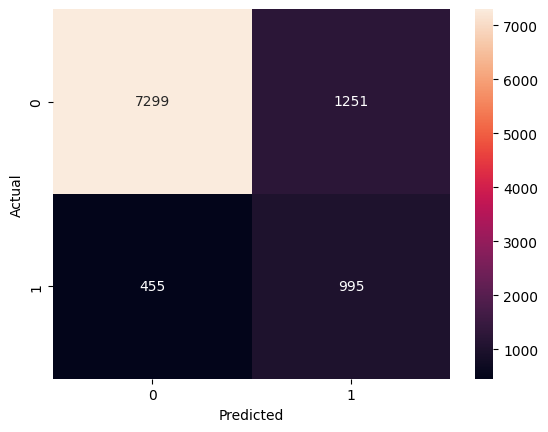

In [174]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [175]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_smote, y_train_smote)
y_pred_svm = svm_model.predict(X_test)

In [176]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.93      0.83      0.88      8550
           1       0.39      0.62      0.47      1450

    accuracy                           0.80     10000
   macro avg       0.66      0.72      0.68     10000
weighted avg       0.85      0.80      0.82     10000



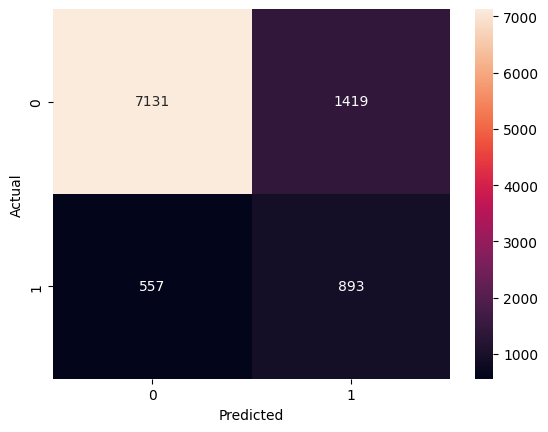

In [177]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [178]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test)

In [179]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.93      0.92      8550
           1       0.49      0.40      0.44      1450

    accuracy                           0.85     10000
   macro avg       0.70      0.66      0.68     10000
weighted avg       0.84      0.85      0.85     10000



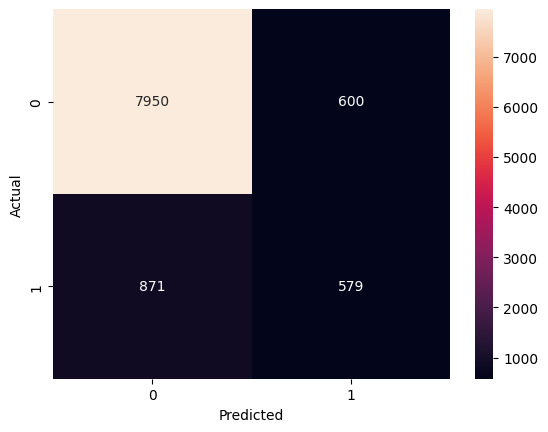

In [180]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [181]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

0.8537334946561805

In [182]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, svm_model.decision_function(X_test))

0.8069080863077234

In [183]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])

0.8485974591651543

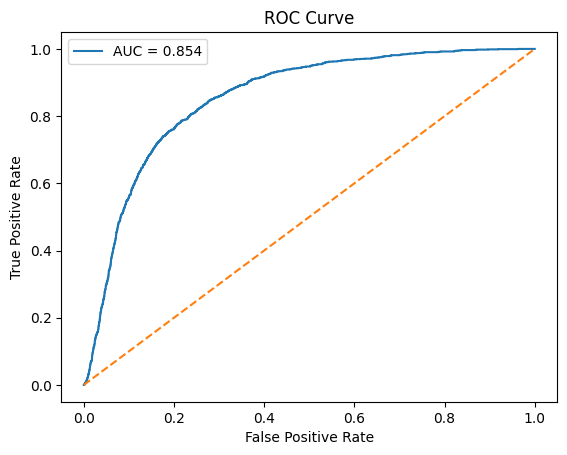

In [184]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [185]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=20, random_state=42)
X_reduced = svd.fit_transform(X_text)

In [186]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_text)

reviews["cluster"] = clusters

In [187]:
reviews["cluster"].value_counts()

cluster
0    13469
9    13278
1     5728
6     5705
5     5388
2     1712
4     1548
3     1540
8     1019
7      613
Name: count, dtype: int64

In [188]:
reviews[reviews["cluster"] == 3]["text"].head(10)

43     Stopped by after a Sunday morning walk in the ...
127    Milktooth is the place to go if you want a goo...
174    This small little donut bakery is located in o...
243    So much to like about this place--the beautifu...
266    Love this bakery!! Great breakfast sandwiches,...
312    Thank you for a lovely morning!  I was in NJ e...
336    Definitely get in line before 8:30am. We waite...
433    So this is what you need to know. Everything t...
474    I will get straight to the point..... If you a...
492    i was looking forward to a new coffee spot, bu...
Name: text, dtype: object

In [189]:
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
for i in range(10):
    print(f"\nCluster {i} top words:")
    for ind in order_centroids[i, :10]:
        print(terms[ind])


Cluster 0 top words:
food
chicken
delicious
place
best
amazing
like
fresh
good
try

Cluster 1 top words:
great
food
service
place
great food
great service
food great
friendly
great place
atmosphere

Cluster 2 top words:
pizza
crust
good
place
great
pizzas
cheese
order
delivery
best

Cluster 3 top words:
coffee
breakfast
great
place
good
coffee shop
shop
love
friendly
nice

Cluster 4 top words:
hotel
room
stay
rooms
stayed
clean
staff
nice
desk
great

Cluster 5 top words:
food
order
minutes
ordered
table
came
just
time
service
got

Cluster 6 top words:
good
food
really
service
place
food good
pretty
really good
good food
nice

Cluster 7 top words:
ice cream
ice
cream
flavors
chocolate
place
good
great
delicious
best

Cluster 8 top words:
sushi
roll
rolls
place
good
fresh
great
best sushi
fish
service

Cluster 9 top words:
time
place
like
just
staff
store
great
love
new
service


In [59]:
pip install vaderSentiment

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [190]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
reviews["sentiment"] = reviews["text"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

In [191]:
reviews.groupby("cluster")["sentiment"].mean()

cluster
0    0.788630
1    0.897245
2    0.694942
3    0.784052
4    0.673977
5    0.355148
6    0.777042
7    0.750273
8    0.746131
9    0.586426
Name: sentiment, dtype: float64

In [192]:
cluster_summary = reviews.groupby("cluster").agg(
    review_count=("text","count"),
    avg_sentiment=("sentiment","mean")
)

cluster_summary.sort_values("avg_sentiment")

,review_count,avg_sentiment
cluster,,
5,5388,0.355148
9,13278,0.586426
4,1548,0.673977
2,1712,0.694942
8,1019,0.746131
7,613,0.750273
6,5705,0.777042
3,1540,0.784052
0,13469,0.788630


In [193]:
cluster_topics = {
0: "food quality",
1: "overall experience",
2: "pizza",
3: "coffee",
4: "hotel rooms",
5: "order waiting time",
6: "general food quality",
7: "ice cream",
8: "sushi",
9: "staff/service"
}

In [194]:
for cluster, row in cluster_summary.iterrows():
    topic = cluster_topics.get(cluster, "other")
    sentiment = row["avg_sentiment"]

    if sentiment > 0.7:
        print(f"{topic} receives very positive feedback.")
    elif sentiment > 0.5:
        print(f"{topic} receives generally positive feedback.")
    else:
        print(f"{topic} receives mixed or negative feedback.")

food quality receives very positive feedback.
overall experience receives very positive feedback.
pizza receives generally positive feedback.
coffee receives very positive feedback.
hotel rooms receives generally positive feedback.
order waiting time receives mixed or negative feedback.
general food quality receives very positive feedback.
ice cream receives very positive feedback.
sushi receives very positive feedback.
staff/service receives generally positive feedback.


In [195]:
import joblib

joblib.dump(model, "../models/fake_review_model.pkl")

['../models/fake_review_model.pkl']

In [196]:
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']

In [197]:
reviews["fake_prob"] = model.predict_proba(X)[:,1]

reviews["fake_flag"] = (reviews["fake_prob"] > 0.6).astype(int)

In [198]:
clean_reviews = reviews[reviews["fake_flag"] == 0]

In [199]:
fake_percent = reviews["fake_flag"].mean() * 100

print("Fake reviews detected:", round(fake_percent,2), "%")

Fake reviews detected: 19.63 %


In [200]:
avg_sentiment = clean_reviews["sentiment"].mean()

trust_score = avg_sentiment * (1 - fake_percent/100) * 10

print("Trust Score:", round(trust_score,2), "/ 10")

Trust Score: 6.68 / 10


In [201]:
positive_features = []
negative_features = []

for cluster, row in cluster_summary.iterrows():
    
    topic = cluster_topics.get(cluster,"other")
    sentiment = row["avg_sentiment"]

    if sentiment > 0.7:
        positive_features.append(topic)

    elif sentiment < 0.5:
        negative_features.append(topic)

In [202]:
print("\nTop Positive Features:")
for f in positive_features:
    print("•", f)

print("\nMost Criticized Feature:")
for f in negative_features:
    print("•", f)


Top Positive Features:
• food quality
• overall experience
• coffee
• general food quality
• ice cream
• sushi

Most Criticized Feature:
• order waiting time


In [203]:
# Improved Trust Score (multi-factor)

avg_sentiment = clean_reviews["sentiment"].mean()
avg_deviation = reviews["rating_deviation"].mean()
fake_percent = reviews["fake_flag"].mean() * 100

trust_score_improved = (
    0.5 * avg_sentiment +
    0.3 * (1 - fake_percent/100) +
    0.2 * (1 - avg_deviation/5)
) * 10

print("Improved Trust Score:", round(trust_score_improved, 2), "/10")

Improved Trust Score: 8.19 /10


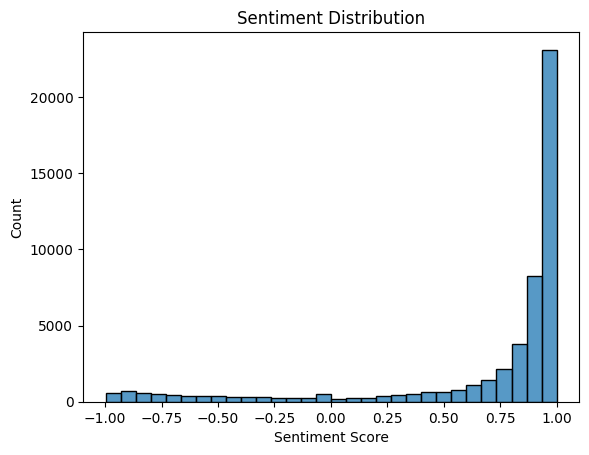

Positive Reviews: 87.86 %
Negative Reviews: 12.14 %


In [204]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sentiment distribution
sns.histplot(reviews["sentiment"], bins=30)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Score")
plt.ylabel("Count")
plt.show()

# Positive vs Negative %
positive = (reviews["sentiment"] > 0).mean() * 100
negative = (reviews["sentiment"] <= 0).mean() * 100

print("Positive Reviews:", round(positive,2), "%")
print("Negative Reviews:", round(negative,2), "%")

In [205]:
# Feature importance from Logistic Regression

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_positive = sorted(zip(coefficients, feature_names), reverse=True)[:10]
top_negative = sorted(zip(coefficients, feature_names))[:10]

print("\nTop words indicating FAKE reviews:")
for coef, word in top_positive:
    print(word, ":", round(coef,3))

print("\nTop words indicating GENUINE reviews:")
for coef, word in top_negative:
    print(word, ":", round(coef,3))


Top words indicating FAKE reviews:
worst : 4.952
terrible : 4.374
tasteless : 4.051
reviews : 4.048
awful : 3.971
mediocre : 3.908
rude : 3.883
flavorless : 3.859
salty : 3.81
disappointment : 3.759

Top words indicating GENUINE reviews:
complaint : -3.316
wont disappointed : -3.156
decent : -3.151
little : -3.113
delicious : -2.999
bit : -2.989
tasty : -2.905
perfect : -2.885
good : -2.77
loved : -2.75


In [83]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/556.1 kB ? eta -:--:--
   ----------------------------------- -- 524.3/556.1 kB 764.3 kB/s eta 0:00:01
   ---------------------------------------- 556.1/556.1 kB 783.9 kB/s  0:00:00
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
    --------------------------------------- 0.8/38.1 MB 2.8 MB/s eta 0:00:14
   - -------------------------------------- 1.0/38.1 MB 2.4 MB/s eta 0:00:16
   - -------------------------------------- 1.8/38.1 MB 2.6 MB/s eta 0:0

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


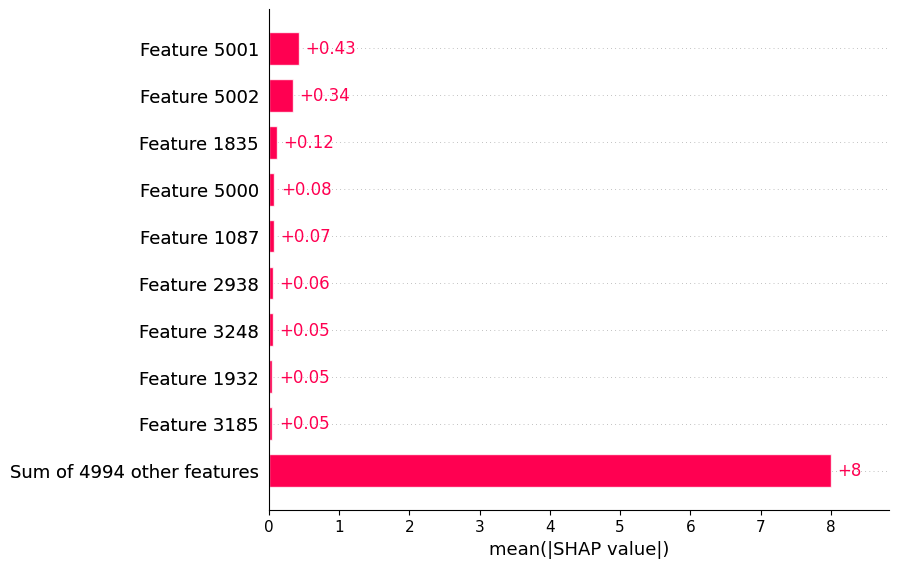

In [206]:
import shap

# Use smaller sample (important for speed)
sample_X = X_train_smote[:500]

explainer = shap.Explainer(model, sample_X)
shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)

In [216]:
def analyze_reviews(reviews_df):
    reviews_df = reviews_df.copy()

    # 🔹 Text preprocessing
    reviews_df["clean_text"] = reviews_df["text"].apply(clean_text)

    # 🔹 Sentiment
    reviews_df["sentiment"] = reviews_df["text"].apply(
        lambda x: analyzer.polarity_scores(x)["compound"]
    )

    # 🔹 TF-IDF transformation
    X_text_new = vectorizer.transform(reviews_df["clean_text"])

    # 🔹 Metadata features
    meta_new = reviews_df[[
        "user_review_count",
        "user_avg_stars",
        "business_avg_stars",
    ]].fillna(0)

    meta_scaled_new = scaler.transform(meta_new)

    from scipy.sparse import hstack
    X_new = hstack([X_text_new, meta_scaled_new])

    # 🔹 Fake review prediction
    fake_prob = model.predict_proba(X_new)[:, 1]
    reviews_df["fake_prob"] = fake_prob
    reviews_df["fake_flag"] = (fake_prob > 0.7).astype(int)

    fake_percent = reviews_df["fake_flag"].mean() * 100

    # 🔹 Remove fake reviews
    clean_reviews = reviews_df[reviews_df["fake_flag"] == 0].copy()

    avg_sentiment = clean_reviews["sentiment"].mean()

    # 🔹 Additional behavioral metrics
    reviews_df["rating_deviation"] = abs(
        reviews_df["stars"] - reviews_df["business_avg_stars"]
    )

    avg_deviation = reviews_df["rating_deviation"].mean()

    # 🔹 Trust Score
    trust_score = (
        0.5 * avg_sentiment +
        0.3 * (1 - fake_percent / 100) +
        0.2 * (1 - avg_deviation / 5)
    ) * 10

    # 🔹 Feature sentiment summary
    positive_features = []
    negative_features = []

    for cluster, row in cluster_summary.iterrows():
        topic = cluster_topics.get(cluster, "other")
        sentiment_val = row["avg_sentiment"]

        if sentiment_val > 0.7:
            positive_features.append(topic)
        elif sentiment_val < 0.5:
            negative_features.append(topic)

    positive_text = ", ".join(positive_features[:3])
    negative_text = ", ".join(negative_features[:2])

    # 🔹 Explainability (FINAL CLEAN VERSION)
    def explain_prediction(prob, text):
        if prob > 0.8:
            return "Highly suspicious review (strong anomaly detected)"
        elif prob > 0.7:
            return "Possibly suspicious review"
        elif prob > 0.5:
            return "Slightly unusual review"
        else:
            return "Likely genuine review"

    # 🔹 Apply explanations
    reviews_df.loc[:, "prediction_explanation"] = reviews_df.apply(
        lambda row: explain_prediction(row["fake_prob"], row["text"]),
        axis=1
    )

    # 🔹 Confidence level
    if fake_percent > 25:
        confidence = "High"
    elif fake_percent > 10:
        confidence = "Moderate"
    else:
        confidence = "Low"

    # 🔹 Final explanation
    explanation = f"""
Customers strongly appreciate {positive_text}.
However, reviews indicate issues related to {negative_text}.

Model Insights:
- Fake reviews detected: {round(fake_percent, 2)}%
- Average sentiment score: {round(avg_sentiment, 2)}

Note:
Negative reviews are not automatically considered fake.
The model detects unusual patterns, not just sentiment.

Final Trust Score: {round(trust_score, 2)}/10
Confidence Level: {confidence}
"""

    return {
        "trust_score": round(trust_score, 2),
        "fake_percent": round(fake_percent, 2),
        "avg_sentiment": round(avg_sentiment, 2),
        "positive_features": positive_features,
        "negative_features": negative_features,
        "explanation": explanation,
        "detailed_results": reviews_df[[
            "text",
            "fake_prob",
            "fake_flag",
            "prediction_explanation"
        ]].head(10)
    }

In [217]:
sample_reviews = reviews.iloc[y_test.index].head(100)
result = analyze_reviews(sample_reviews)
print(result)

{'trust_score': np.float64(7.81), 'fake_percent': np.float64(16.0), 'avg_sentiment': np.float64(0.73), 'positive_features': ['food quality', 'overall experience', 'coffee', 'general food quality', 'ice cream', 'sushi'], 'negative_features': ['order waiting time'], 'explanation': '\nCustomers strongly appreciate food quality, overall experience, coffee.\nHowever, reviews indicate issues related to order waiting time.\n\nModel Insights:\n- Fake reviews detected: 16.0%\n- Average sentiment score: 0.73\n\nNote:\nNegative reviews are not automatically considered fake.\nThe model detects unusual patterns, not just sentiment.\n\nFinal Trust Score: 7.81/10\nConfidence Level: Moderate\n', 'detailed_results':                                                     text  fake_prob  \
33553  Great location but the place is very tiny.   Y...   0.815408   
9427   WARNING: HORRIBLE!\n\nI absolutely love BBQ an...   0.755628   
199    I stopped in for dinner and a drink & was thor...   0.027802   
12447  

In [218]:
y_prob = model.predict_proba(X_test)[:,1]

test_results = pd.DataFrame({
    "Actual_Label": y_test.values,
    "Predicted_Label": y_pred,
    "Fake_Probability": y_prob
})

test_results.head(20)

,Actual_Label,Predicted_Label,Fake_Probability
0,0,1,0.815408
1,1,1,0.755628
2,0,0,0.027802
3,0,0,0.092238
4,1,1,0.883950
5,0,0,0.097641
6,0,0,0.017815
7,0,0,0.182945
8,0,0,0.133925
9,1,0,0.249750


In [219]:
test_examples = reviews.iloc[y_test.index]

results = pd.DataFrame({
    "Review": test_examples["text"],
    "Actual_Label": y_test.values,
    "Predicted_Label": y_pred,
    "Fake_Probability": y_prob
})

results.head(10)

,Review,Actual_Label,Predicted_Label,Fake_Probability
33553,Great location but the place is very tiny. Y...,0,1,0.815408
9427,WARNING: HORRIBLE!\n\nI absolutely love BBQ an...,1,1,0.755628
199,I stopped in for dinner and a drink & was thor...,0,0,0.027802
12447,If you're looking for fresh spins on the class...,0,0,0.092238
39489,We purchased the 8 piece fried chicken from th...,1,1,0.883950
42724,"Unfortunately, this visit wasn't as good as th...",0,0,0.097641
10822,Not only is this place delicious (brussel spro...,0,0,0.017815
49498,Just getting around to writing this review. W...,0,0,0.182945
4144,At this stage in my life to finally get to see...,0,0,0.133925
36958,Outstanding!! I have a German Shepard that sh...,1,0,0.249750


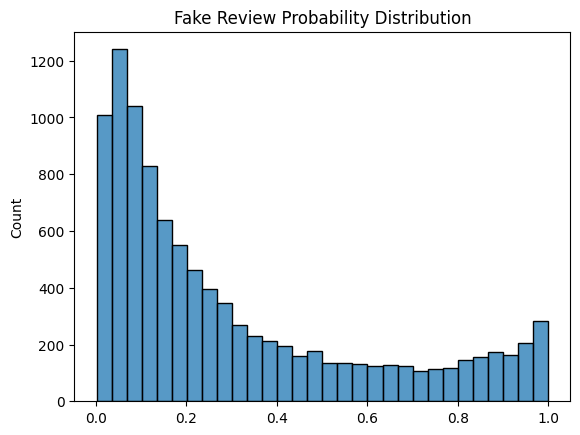

In [220]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(y_prob, bins=30)
plt.title("Fake Review Probability Distribution")
plt.show()

In [221]:
result = analyze_reviews(sample_reviews)

print(result["explanation"])
result["detailed_results"]


Customers strongly appreciate food quality, overall experience, coffee.
However, reviews indicate issues related to order waiting time.

Model Insights:
- Fake reviews detected: 16.0%
- Average sentiment score: 0.73

Note:
Negative reviews are not automatically considered fake.
The model detects unusual patterns, not just sentiment.

Final Trust Score: 7.81/10
Confidence Level: Moderate



,text,fake_prob,fake_flag,prediction_explanation
33553,Great location but the place is very tiny. Y...,0.815408,1,Highly suspicious review (strong anomaly detec...
9427,WARNING: HORRIBLE!\n\nI absolutely love BBQ an...,0.755628,1,Possibly suspicious review
199,I stopped in for dinner and a drink & was thor...,0.027802,0,Likely genuine review
12447,If you're looking for fresh spins on the class...,0.092238,0,Likely genuine review
39489,We purchased the 8 piece fried chicken from th...,0.883950,1,Highly suspicious review (strong anomaly detec...
42724,"Unfortunately, this visit wasn't as good as th...",0.097641,0,Likely genuine review
10822,Not only is this place delicious (brussel spro...,0.017815,0,Likely genuine review
49498,Just getting around to writing this review. W...,0.182945,0,Likely genuine review
4144,At this stage in my life to finally get to see...,0.133925,0,Likely genuine review
36958,Outstanding!! I have a German Shepard that sh...,0.249750,0,Likely genuine review
